In [1]:
import pyarrow
import math
from glob import glob
from GLMCollection import *

# Preprocessing of the features and metadata to format the dataframes

The GLMCollection assumes we are looking at overall proportions, parent/child proportions, densities, and spatial correlation dataframes with columns following specific naming conventions. These assumptions are used in the `get_celltype_annot_region_feature_type()` function in `statsmodels_utils.py` and the `add_model()` function in the `GLMCollection` class. **If your features are named differently you will have to change these functions**


### Conventions:

`cell_category` = broad category of cell labels, e.g. primary_celltype, secondary_celltype, tertiary_celltype, niche

`celltype` = specific value from cell_category, e.g. Myeloid from primary_celltypes, fibroblast from secondary_celltype

`region` = Integer value from annotated region. For the HPV project we only have two values: 2 = Stromal, 3 = Epithelial

* Proportion conventions
   * Column containing actual proportions saved as `{cell_category}_proportion_per_annot_region_{region}___{celltype}`
   * Column containing counts of given celltype saved as `{cell_category}_counts_per_annot_region_{region}___{celltype}`
   * Column containing total number of cells saved as `total_counts_per_annot_region_{region}`
* Parent/child proportions (eg secondary celltype per primary type, such as B_cells per B_plasma cells)
   * Column containing actual proportions saved as `{child_cell_category}_celltype_proportion_per_{parent_celltype}_per_annot_region_{region}___{child_celltype}`
   * Column containing count of child celltype saved as `{child_cell_category}_celltype_counts_per_annot_region_{region}___{child_celltype}`
   * Column containing count of parent celltype saved as `{parent_cell_category}_celltype_counts_per_annot_region_{region}___{parent_celltype}`
* Densities
   * Column containing densities saved as `{cell_category}_density_per_annot_region_{region}___{celltype}`
   * Column containing counts of given celltype saved as `{cell_category}_counts_per_annot_region_{region}___{celltype}`
   * Column containing area of given region saved as `annot{region}_area`
* Spatial Correlations
    * Column containing spatial correlation (w+1) saved as `{cell_category}_spatial_correlation_central_cell_{central_celltype}_radius_{radius_in_microns}_annot_region_{region}___{surrounding_celltype}`
    * Column containing number of expected cells saved as `{cell_category}_expected_count_central_cell_{central_celltype}_radius_{radius_in_microns}_annot_region_{region}___{surrounding_celltype}`
    * Column containing number of observed cells saved as `{cell_category}_observed_count_central_cell_{central_celltype}_radius_{radius_in_microns}_annot_region_{region}___{surrounding_celltype}`
* Codetection / Covering Fraction
   * Columns containing covering fraction saved as `{cell_category}_covering_fraction_{celltype_1}_radius_{radius}_annot_region_{region}___{celltype_2}`
   * Columns containing number of pixels from overlapping cell types saved as `{cell_category}_n_pixels_{celltype_1}_radius_{radius}_annot_region_{region}___{celltype_2}`
   * Columns containing total pixels for the area saved as `{cell_category}_total_pixels_{celltype_1}_radius_{radius}_annot_region_{region}___{celltype_2}`

These features also have columns calculated for the entire core (not per region) but I don't use them for anything

Read in the metadata

In [2]:
metadata = pd.read_csv('/common/knottsilab/xenium/hpv/metadata.csv', index_col = 0)
metadata.head(5)

,Unique TMA sample ID,TMA Block ID,TMA Block Name,Donor Block Images,Donor Core Height,core_idx,slide_idx,slide,batch,KEY,...,Diagnosis,Sex,TMA,TMA_position,HPV_7,LR_HPV,No_SIL,LSIL,HSIL,Core_index
0,2.0,RB_1,AnoGen TMA #1,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,4.16 mm,2.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,UM5BJU,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,RB_1,AnoGen TMA #1,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,2.715 mm,3.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,S89IB7,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,RB_1,AnoGen TMA #1,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,3.997 mm,4.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,VBEJVL,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.0,RB_1,AnoGen TMA #1,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,3.799 mm,5.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,VI8D2D,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.0,RB_1,AnoGen TMA #1,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,4.16 mm,6.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,UM5BJU,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Read in the features and areas

In [3]:
prop_densities = pd.read_csv('/common/lamt2/HPV/data/features/features_08_18_25/prop_densities.csv', index_col = 0)
prop_densities.head(5)

,primary_celltype_proportion___B_plasma,primary_celltype_proportion___Epithelial,primary_celltype_proportion___Mast_cell,primary_celltype_proportion___Myeloid,primary_celltype_proportion___NOS,primary_celltype_proportion___Stromal,primary_celltype_proportion___TNK,primary_celltype_proportion___muscle,primary_celltype_proportion___neural,secondary_celltype_proportion___B_cell,...,niche_cellcharter_counts_per_annot_region_2___27,niche_cellcharter_counts_per_annot_region_3___27,niche_cellcharter_counts_per_annot_region_2___28,niche_cellcharter_counts_per_annot_region_3___28,niche_cellcharter_counts_per_annot_region_2___29,niche_cellcharter_counts_per_annot_region_3___29,niche_cellcharter_counts_per_annot_region_2___30,niche_cellcharter_counts_per_annot_region_3___30,total_counts_per_annot_region_2,total_counts_per_annot_region_3
batch,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,0.001053,0.587172,0.000124,0.029470,0.314636,0.060674,0.006872,0.0,0.000000,0.000310,...,0,0,0,0,0,0,4566,3,5622,10530
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___2,0.017634,0.233117,0.008004,0.113307,0.077539,0.380690,0.169460,0.0,0.000250,0.002626,...,235,0,0,0,0,0,45,0,6594,1402
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___5,0.002042,0.612658,0.005011,0.063289,0.098738,0.211210,0.007053,0.0,0.000000,0.000000,...,0,0,0,0,0,0,3,0,1913,3475
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___6,0.028130,0.500080,0.002993,0.060969,0.092850,0.215226,0.098635,0.0,0.001117,0.005945,...,2721,67,0,0,0,0,47,0,8111,16951
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___7,0.125209,0.329834,0.002860,0.081948,0.274358,0.116181,0.069570,0.0,0.000041,0.031496,...,1003,44,0,0,676,3199,764,2,16052,8427


In [4]:
areas = pd.read_csv('/common/lamt2/HPV/data/features/features_08_18_25/areas_df.csv', index_col = 0)
areas = areas.drop(['slide', 'core_idx'], axis = 1)

# Convert areas from um^2 to mm^2
areas['core_area'] = areas['core_area'] / (1000**2)
areas['annot2_area'] = areas['annot2_area'] / (1000**2)
areas['annot3_area'] = areas['annot3_area'] / (1000**2)

prop_densities = pd.merge(prop_densities, areas, left_index = True, right_index = True, how = 'left')
areas.head(2)

,core_area,annot2_area,annot3_area
batch,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,1.774351,0.472998,1.301354
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___2,2.068467,1.890445,0.178023


Read in spatial correlations (and do a lot of reformatting)

In [5]:
spatial_dfs = {}
for feat in ['primary_celltype']: # Only read in primary celltype for this example
    spatial_dfs[feat] = {}
    spatial_files = glob(f'/common/lamt2/HPV/data/features/features_08_18_25/spatial_correlation*{feat}*.gzip')
    for f in tqdm(spatial_files, desc = f'Reading spatial correlations for {feat}'):
        name = f.split('/')[-1].split('.gzip')[0]
        spatial_dfs[feat][name] = pd.read_parquet(f)

merged_spatial_dfs = {}
for feat in ['primary_celltype']:
    merged_spatial_dfs[feat] = pd.DataFrame()
    for name in spatial_dfs[feat]:
        spatial_dfs[feat][name] = spatial_dfs[feat][name][spatial_dfs[feat][name]['region_1'] == spatial_dfs[feat][name]['region_2']]
        spatial_dfs[feat][name]['spatial_correlation'] = spatial_dfs[feat][name]['corr_coefficient'] + 1
        spatial_dfs[feat][name]['expected_count'] = spatial_dfs[feat][name]['permutation_counts'].apply(lambda x: x.mean())
        spatial_dfs[feat][name]['feature'] = spatial_dfs[feat][name].apply(lambda x: f'{feat}_spatial_correlation_central_cell_{x[f"{feat}_1"]}_radius_{x["radius"]}_annot_region_{x["region_1"]}___{x[f"{feat}_2"]}', axis = 1)
        pivot = spatial_dfs[feat][name].pivot(index = 'spatial_key', columns = 'feature', values = ['spatial_correlation', 'observed_count', 'expected_count'])
        pivot.columns = [f"{c[1].replace('spatial_correlation', c[0])}" for c in pivot.columns]
        merged_spatial_dfs[feat] = pd.concat([merged_spatial_dfs[feat], pivot], axis = 0, join = 'outer')
spatial_dfs_all = pd.concat([df for df in merged_spatial_dfs.values()], axis= 1, join = 'outer')

spatial_dfs_all.head(5)

Reading spatial correlations for primary_celltype: 100%|██████████| 10/10 [00:12<00:00,  1.29s/it]


,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___B_plasma,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Epithelial,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Mast_cell,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Myeloid,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___NOS,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Stromal,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___TNK,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___muscle,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___neural,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_3___B_plasma,...,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_2___neural,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___B_plasma,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Epithelial,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Mast_cell,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Myeloid,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___NOS,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Stromal,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___TNK,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___muscle,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___neural
spatial_key,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___1,4.704856,0.094688,1.272400,0.967349,0.740675,0.675078,1.250433,NaN,0.295281,0.854792,...,0.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___10,6.014972,0.041562,1.989866,1.624610,1.018536,0.963748,1.895500,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___12,4.197317,0.081384,3.154308,3.123361,1.517362,2.573593,3.643024,NaN,NaN,1.488710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___13,6.510200,0.014229,2.919811,3.054394,2.232780,3.621723,3.827747,NaN,NaN,4.436966,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___14,2.263269,0.042014,0.837876,1.107257,0.850157,1.106877,1.055974,NaN,0.551788,0.108967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Read in covering fractions and do a lot of formatting.

In [6]:
codetection = pd.read_csv('/common/lamt2/HPV/data/features/features_08_18_25/pairwise_covering_fraction.csv', index_col = 0)
codetection = codetection[codetection['region'] > 0].copy()
codetection = codetection[codetection['column'] == 'primary_celltype']
pivot = codetection.pivot(index = 'batch', columns = ['column', 'region', 'category1', 'category2', 'radius'], values = ['covering_fraction', 'n_pixels', 'total_pixels'])
col_names = [f'{c[1]}_{c[0]}_{c[3]}_radius_{c[5]}_annot_region_{c[2]}___{c[4]}' for c in pivot.columns]
pivot.columns = col_names
codetection_df = pivot

codetection_df.head(5)

,primary_celltype_covering_fraction_Epithelial_radius_5_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_10_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_20_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_50_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_5_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_10_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_20_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_50_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_5_annot_region_2___TNK,primary_celltype_covering_fraction_Epithelial_radius_10_annot_region_2___TNK,...,primary_celltype_total_pixels_TNK_radius_20_annot_region_3___muscle,primary_celltype_total_pixels_TNK_radius_50_annot_region_3___muscle,primary_celltype_total_pixels_Mast_cell_radius_5_annot_region_3___muscle,primary_celltype_total_pixels_Mast_cell_radius_10_annot_region_3___muscle,primary_celltype_total_pixels_Mast_cell_radius_20_annot_region_3___muscle,primary_celltype_total_pixels_Mast_cell_radius_50_annot_region_3___muscle,primary_celltype_total_pixels_B_plasma_radius_5_annot_region_3___muscle,primary_celltype_total_pixels_B_plasma_radius_10_annot_region_3___muscle,primary_celltype_total_pixels_B_plasma_radius_20_annot_region_3___muscle,primary_celltype_total_pixels_B_plasma_radius_50_annot_region_3___muscle
batch,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,0.000588,0.010331,0.056715,0.275473,0.002740,0.047174,0.183814,0.612352,0.000263,0.003431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___10,0.000756,0.026944,0.180187,0.654159,0.003371,0.073270,0.299066,0.860654,0.000101,0.003055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___12,0.000222,0.010237,0.142894,0.746860,0.000087,0.004521,0.044330,0.261704,0.000157,0.004482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___14,0.001283,0.026541,0.137466,0.415244,0.001875,0.048574,0.243201,0.754060,0.001451,0.027229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___15,0.000025,0.000577,0.004941,0.049687,NaN,NaN,NaN,NaN,0.000008,0.000304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Merge the features and metadata. Your final features dataframe should be indexed by core and have columns corresponding to the metadata and features

In [7]:
features_df = pd.merge(prop_densities, spatial_dfs_all, left_index = True, right_index = True, how = 'outer')
features_df = pd.merge(features_df, codetection_df, left_index = True, right_index = True, how = 'outer')
features_df = pd.merge(features_df, metadata, left_index = True, right_on = 'batch', how = 'left')
features_df.index = features_df['batch']

features_df.head(5)

,primary_celltype_proportion___B_plasma,primary_celltype_proportion___Epithelial,primary_celltype_proportion___Mast_cell,primary_celltype_proportion___Myeloid,primary_celltype_proportion___NOS,primary_celltype_proportion___Stromal,primary_celltype_proportion___TNK,primary_celltype_proportion___muscle,primary_celltype_proportion___neural,secondary_celltype_proportion___B_cell,...,Diagnosis,Sex,TMA,TMA_position,HPV_7,LR_HPV,No_SIL,LSIL,HSIL,Core_index
batch,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,0.001053,0.587172,0.000124,0.029470,0.314636,0.060674,0.006872,0.000000,0.000000,0.000310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___10,0.000198,0.444433,0.000346,0.061938,0.414452,0.070137,0.008496,0.000000,0.000000,0.000049,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___12,0.032517,0.540696,0.021315,0.072370,0.081293,0.227521,0.021414,0.000099,0.002776,0.000198,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___14,0.008757,0.741144,0.002162,0.035136,0.067498,0.106743,0.038524,0.000000,0.000036,0.000360,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___15,0.002538,0.022843,0.002538,0.038917,0.562606,0.334179,0.036379,0.000000,0.000000,0.000846,...,Invasive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Now we make the GLMCollection class that stores all of the regression models, then we fit and do permutation tests

First we setup the comparison we want to make:

We are interested in comparing diagnosis stage (no_sil, lsil, hsil, invasive) for squamous cell, p53-, HPV- patients

In [8]:
# col:val pairs for preselection. All patients used in the comparison must match this criteria
preselection = {
    'SCC_ADENO': 'SCC',
    'P53': 0,
}

# Key(s) for pseudobulking. We are pseudobulking per patient
group_key = ['Accession_no']

# Columns we are using for our predictors: we want to see differences in diagnosis stages
comparisons = ['Diagnosis']

In [9]:
# A quick filtering of our dataset to trim very low stats categories:
sub_feature_df = features_df[features_df['Diagnosis'] != 'SIL_ungraded'].copy()

# Make the glmcollection
glms = GLMCollection(sub_feature_df, preselection, group_key, comparisons)

Add primary celltype/niche proportions and primary celltype spatial correlations to the model

In general you want to fit features in batches

In [10]:
# List of celltype comparisons to skip
skip = defaultdict(list)
skip['primary_celltype'] = ['NOS', 'muscle', 'neural'] # Skip primary celltypes with too limited statistics for comparisons
skip['secondary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural'] # Skip when primary celltype only has 1 secondary celltype
skip['tertiary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural', 'Epithelial', 'Epithelial_glandular', 'Epithelial_mixed', 'Epithelium_neuroendocrine', 'NK_gdT', 'pDC'] # Skip when secondary celltype only has 1 tertiary celltype

#cols_to_add = [c for c in sub_feature_df.columns if 'primary_celltype_proportion_per_annot_region' in c or 'niche_cellcharter_proportion_per_annot_region' in c or 'primary_celltype_spatial_correlation' in c]
cols_to_add = [c for c in sub_feature_df.columns if 'primary_celltype_proportion_per_annot_region' in c or 'primary_celltype_spatial_correlation' in c]

glms.add_models_batch(cols_to_add, skip = skip, verbose = True)

Creating Models from Batch: 100%|██████████| 300/300 [00:02<00:00, 111.49it/s]


Fit the models and the null models

In [11]:
glms.fit_models_parallel(verbose = True)
glms.fit_null_models_parallel(verbose = True)

Fitting null models: 100%|██████████| 300/300 [00:00<00:00, 1319.12it/s]


In [12]:
# for an example of the fit outputs:
print(glms.results['primary_celltype_proportion_per_annot_region_3___Epithelial'].summary())

                               BetaGLM Results                                
Dep. Variable:                   rate   Log-Likelihood:                 177.60
Model:                        BetaGLM   AIC:                            -345.2
Method:            Maximum Likelihood   BIC:                            -326.8
Date:                Thu, 18 Dec 2025                                         
Time:                        11:31:19                                         
No. Observations:                 294                                         
Df Residuals:                     289                                         
Df Model:                           3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.0362      0.118      8.789      0.000       0.805       1.267
Diagnosis[T.Invasiv

Use `GLMCollection.plot_model()` to display the distributions for each category:

Top plot = Normalized histograms for each category (optional overlaid with best fit distribution)

Bottom plot = Strip plot for each category (if fitted, use an envelope of the best fit distribution. Otherwise use a violin plot)

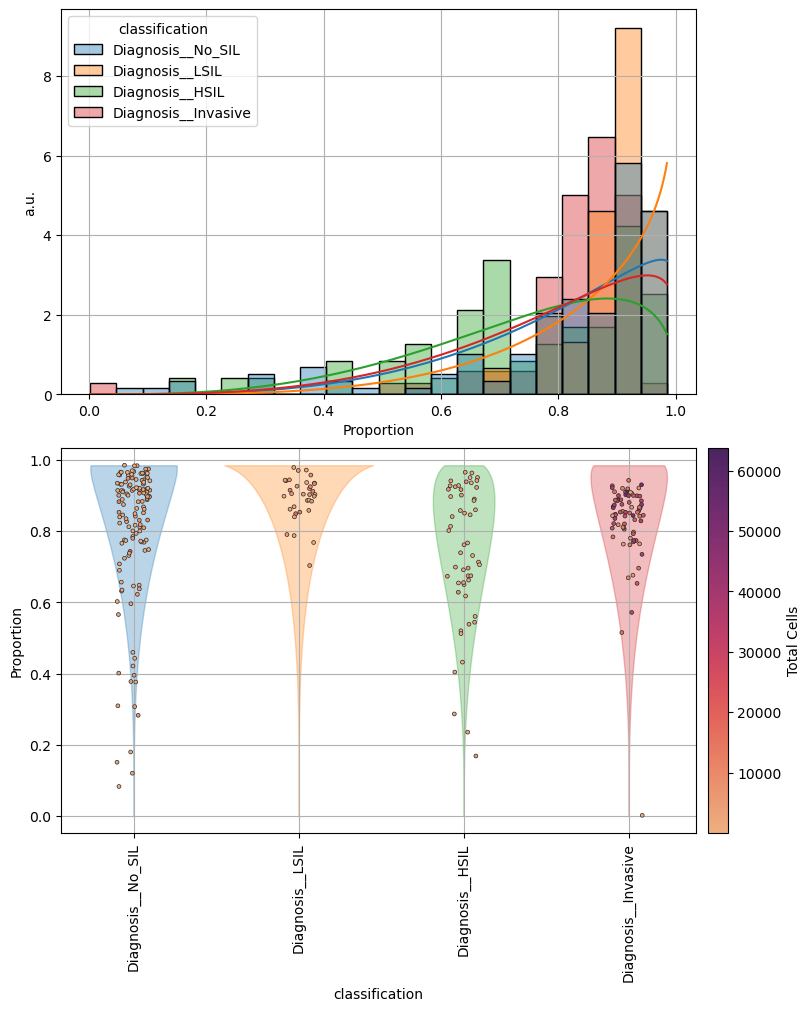

In [13]:
glms.plot_model(
    'primary_celltype_proportion_per_annot_region_3___Epithelial', #Which feature are we plotting
    fitted = True, # If true, use the fitted distribution of the means
    order = ['Diagnosis__No_SIL', 'Diagnosis__LSIL', 'Diagnosis__HSIL', 'Diagnosis__Invasive'], # From left->right, order of categories in the violin plot
    ax_label = 'Proportion',
    cbar_label = 'Total Cells'
)

Do the permutation testing for the likelihood ratio tests

In [14]:
# Optional step is to check whether to do inner or outer parallelism
# Depending on number of jobs/models/nodes, sometimes it is faster to run each permutation in parallel
# Other times it may be faster to run permutations in series but parallelize the model fitting
# Due to joblib limitations we cannot do nested parallelism
# These are very rough estimates.

jobs_dict = glms.test_run(n_perm = 200)
print(jobs_dict)

# If you don't want to do the test run, in general this will be 
# the fastest if you have many features

#jobs_dict = {'n_jobs': multiprocessing.cpu_count() -1, 'n_jobs_inner': 1}

Running test permutations to job allocation
   Running test with inner parallelism ... done: 24.94 s
   Running test with outer parallelism ... done: 52.85 s
Estimated time with inner parallelism: 83.13 min
Estimated time with outer parallelism: 4.40 min
{'n_jobs': 47, 'n_jobs_inner': 1}


In [15]:
import multiprocessing
n_jobs = int(multiprocessing.cpu_count())
stat_res = glms.run_stats_with_permutations(
    n_permutations = 200, # number of permutations (null distribution will have <= n_permutations * n_features test stats). We're only doing 200 for brevity. Generally I'll do 1000
    **jobs_dict, # Job allocation for inner/outer parallelism from test_run()
    random_state = 42, # For reproducibility. If you split your jobs you must set this so permutations can be combined between different jobs
    do_pairwise = False, # We're only doing the LLR test in this iteration. No pairwise comparisons
)

Calculating permutations: 100%|██████████| 200/200 [01:23<00:00,  2.40it/s]


Since we didn't do pairwise comparisons, the only output is the LLR results

In [16]:
list(stat_res.keys())

['llr']

The 'llr' result contains a dataframe with the feature test stats/p-values and a 'perm_df' dataframe with all of the permutation results

The relevant column is `p-nom`: The nominal, empirical p-value, calculated from the tail of the null distribution

In [17]:
stat_res['llr']['df'].head(5)

,stat,Celltype,Region,feature_type,p-nom
feature,,,,,
primary_celltype_proportion_per_annot_region_2___B_plasma,22.174483,B_plasma,Stroma,primary_celltype_proportion,0.004975
primary_celltype_proportion_per_annot_region_3___B_plasma,7.597877,B_plasma,Epithelium,primary_celltype_proportion,0.004975
primary_celltype_proportion_per_annot_region_2___Epithelial,17.827884,Epithelial,Stroma,primary_celltype_proportion,0.004975
primary_celltype_proportion_per_annot_region_3___Epithelial,11.507967,Epithelial,Epithelium,primary_celltype_proportion,0.009950
primary_celltype_proportion_per_annot_region_2___Mast_cell,4.854512,Mast_cell,Stroma,primary_celltype_proportion,0.134328


In [18]:
stat_res['llr']['perm_df'].head(5)

,stat,Celltype,Region,feature_type,perm_iter
feature,,,,,
primary_celltype_proportion_per_annot_region_2___B_plasma,12.071477,B_plasma,Stroma,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_3___B_plasma,2.458592,B_plasma,Epithelium,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_2___Epithelial,4.211588,Epithelial,Stroma,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_3___Epithelial,0.937251,Epithelial,Epithelium,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_2___Mast_cell,1.910332,Mast_cell,Stroma,primary_celltype_proportion,0


# Now to do the FDR correction 

We use the Benjamini-Bogomolov method of FDR correction. A rough outline:
* Calculate the spearman correlation between all features using the permutations
* Use hierarchical clustering to group features into families
* Calculate the simes p-value for each family and select significant families
* Calculate the B.B. adjusted significance threshold based on # significant families / # total families
* Apply BH correction within families and select significant features using the B.B. adjusted significance

Running Benjamini-Bogomolov selection criteria based on permutation clusters
   Calculating correlation distance matrix


Calculating correlation matrix:   0%|          | 0/300 [00:00<?, ?it/s]

done: 0.01 min
   Calculating Distance and linkage matrix ... done: 0.00 min


Calculating silhouette scores: 100%|██████████| 100/100 [00:00<00:00, 598.43it/s]

   Clustering at threshold t = 0.404


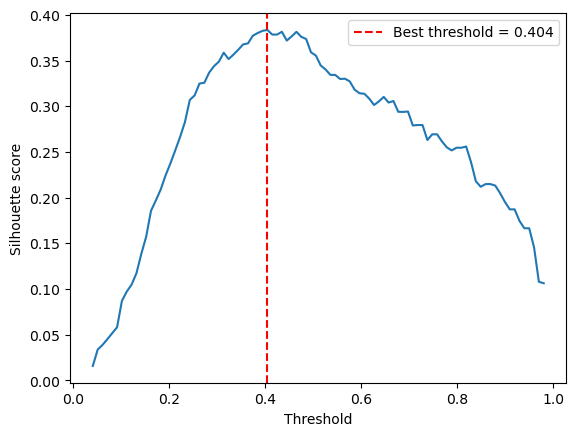

Done with FDR corrections: 0.02 min


,stat,Celltype,Region,feature_type,p-nom,cluster,p-simes,cluster-p-adj,signif,fdr-q-val
feature,,,,,,,,,,
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_100_annot_region_2___Epithelial,7.548675,Epithelial,Stroma,primary_celltype_spatial_correlation_central_c...,0.129353,1,0.129353,0.129353,False,0.278779
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_200_annot_region_2___Epithelial,7.595597,Epithelial,Stroma,primary_celltype_spatial_correlation_central_c...,0.104478,1,0.129353,0.129353,False,0.278779
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_20_annot_region_2___Epithelial,13.694407,Epithelial,Stroma,primary_celltype_spatial_correlation_central_c...,0.099502,1,0.129353,0.129353,False,0.278779
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_50_annot_region_2___Epithelial,9.776253,Epithelial,Stroma,primary_celltype_spatial_correlation_central_c...,0.114428,1,0.129353,0.129353,False,0.278779
primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Epithelial,7.218081,Epithelial,Stroma,primary_celltype_spatial_correlation_central_c...,0.482587,2,0.723881,0.723881,False,1.000000
...,...,...,...,...,...,...,...,...,...,...
primary_celltype_spatial_correlation_central_cell_Stromal_radius_100_annot_region_3___Mast_cell,24.934259,Mast_cell,Epithelium,primary_celltype_spatial_correlation_central_c...,0.004975,124,0.004975,0.004975,True,0.010722
primary_celltype_spatial_correlation_central_cell_Stromal_radius_200_annot_region_3___Mast_cell,16.419690,Mast_cell,Epithelium,primary_celltype_spatial_correlation_central_c...,0.004975,124,0.004975,0.004975,True,0.010722
primary_celltype_spatial_correlation_central_cell_Stromal_radius_20_annot_region_3___Mast_cell,25.740568,Mast_cell,Epithelium,primary_celltype_spatial_correlation_central_c...,0.004975,124,0.004975,0.004975,True,0.010722


In [19]:
# If you want the fast version of this, you can just run this command and skip the following steps:
perm_df = stat_res['llr']['perm_df'].copy()
llr_df = stat_res['llr']['df'].copy()

signif_df = run_fdr_corrections(perm_df, llr_df, alpha = 0.05, plot_threshold = True)

### 5 new columns added to the llr_df:
# cluster: Which cluster the feature is in
# cluster-p-adj: within cluster BH corrected p-value
# p-simes: simes p-value calculated for each cluster
# signif: If feature passes final significance threshold
# fdr-q-val: (Loosely interpreted) significance threshold at which feature would reject the null hypothesis

signif_df

In [20]:
# Look at significant features
signif_df[signif_df['signif']]

,stat,Celltype,Region,feature_type,p-nom,cluster,p-simes,cluster-p-adj,signif,fdr-q-val
feature,,,,,,,,,,
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_50_annot_region_2___Stromal,16.178240,Stromal,Stroma,primary_celltype_spatial_correlation_central_c...,0.004975,7,0.009950,0.009950,True,0.021445
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_100_annot_region_2___B_plasma,16.329805,B_plasma,Stroma,primary_celltype_spatial_correlation_central_c...,0.009950,10,0.007463,0.009950,True,0.021445
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_20_annot_region_2___B_plasma,31.109929,B_plasma,Stroma,primary_celltype_spatial_correlation_central_c...,0.004975,10,0.007463,0.007463,True,0.016083
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_50_annot_region_2___B_plasma,35.807941,B_plasma,Stroma,primary_celltype_spatial_correlation_central_c...,0.004975,10,0.007463,0.007463,True,0.016083
primary_celltype_spatial_correlation_central_cell_Stromal_radius_20_annot_region_2___Stromal,39.540323,Stromal,Stroma,primary_celltype_spatial_correlation_central_c...,0.004975,22,0.009950,0.009950,True,0.021445
...,...,...,...,...,...,...,...,...,...,...
primary_celltype_spatial_correlation_central_cell_Epithelial_radius_50_annot_region_3___Mast_cell,16.963808,Mast_cell,Epithelium,primary_celltype_spatial_correlation_central_c...,0.004975,123,0.004975,0.004975,True,0.010722
primary_celltype_spatial_correlation_central_cell_Stromal_radius_100_annot_region_3___Mast_cell,24.934259,Mast_cell,Epithelium,primary_celltype_spatial_correlation_central_c...,0.004975,124,0.004975,0.004975,True,0.010722
primary_celltype_spatial_correlation_central_cell_Stromal_radius_200_annot_region_3___Mast_cell,16.419690,Mast_cell,Epithelium,primary_celltype_spatial_correlation_central_c...,0.004975,124,0.004975,0.004975,True,0.010722


Plot the difference in nominal p-value and fdr corrected q-value

Text(0, 0.5, 'FDR adjusted p-value')

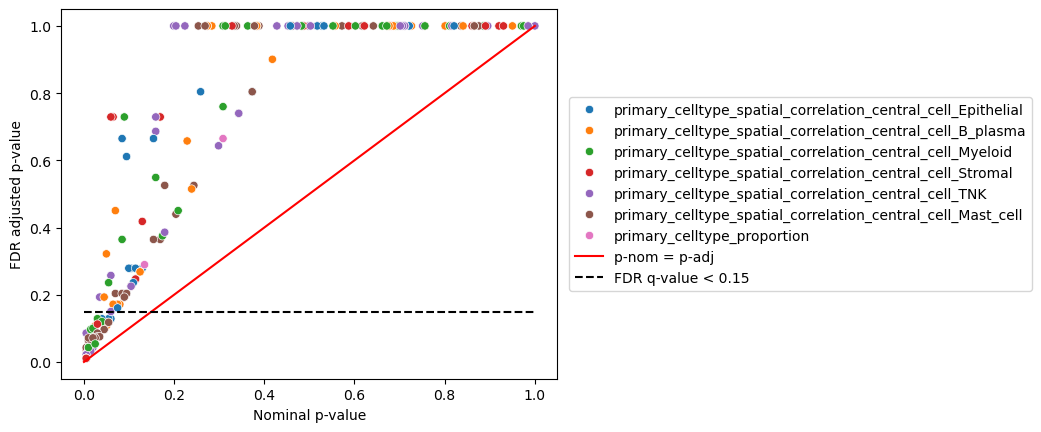

In [21]:
sns.scatterplot(x = 'p-nom', y = 'fdr-q-val', data = signif_df, hue = 'feature_type')
plt.plot([0, 1], [0, 1], 'r-', label = 'p-nom = p-adj')
plt.plot([0, 1], [0.15, 0.15], '--', c = 'black', label = 'FDR q-value < 0.15')
plt.legend(loc = 'center left', bbox_to_anchor = (1.01, 0.5))
plt.xlabel("Nominal p-value")
plt.ylabel("FDR adjusted p-value")

# Now that we have the significant features, we have to do the pairwise testing

* Previously we permuted all patients across all stages
* For pairwise comparisons, we only want to look at patients within the two groups we're comparing

There is probably a much better way to do this but here's what I currently do

First we have to define the contrasts for the pairwise comparisons

In [22]:
contrasts = []
for c1, c2 in combinations(glms.features_raw['Diagnosis'].unique(), 2):
    # Name for the comparison
    name = f'Diagnosis___{c1}_vs_{c2}'
    # Dictionaries defining the reference and test group
    ref = dict(Diagnosis = c1)
    test = dict(Diagnosis = c2)
    # Dictionary to hold contrast results
    meta = {'name': name, 'test': test, 'ref': ref}
    contrasts.append(meta)
contrasts

[{'name': 'Diagnosis___Invasive_vs_No_SIL',
  'test': {'Diagnosis': 'No_SIL'},
  'ref': {'Diagnosis': 'Invasive'}},
 {'name': 'Diagnosis___Invasive_vs_HSIL',
  'test': {'Diagnosis': 'HSIL'},
  'ref': {'Diagnosis': 'Invasive'}},
 {'name': 'Diagnosis___Invasive_vs_LSIL',
  'test': {'Diagnosis': 'LSIL'},
  'ref': {'Diagnosis': 'Invasive'}},
 {'name': 'Diagnosis___No_SIL_vs_HSIL',
  'test': {'Diagnosis': 'HSIL'},
  'ref': {'Diagnosis': 'No_SIL'}},
 {'name': 'Diagnosis___No_SIL_vs_LSIL',
  'test': {'Diagnosis': 'LSIL'},
  'ref': {'Diagnosis': 'No_SIL'}},
 {'name': 'Diagnosis___HSIL_vs_LSIL',
  'test': {'Diagnosis': 'LSIL'},
  'ref': {'Diagnosis': 'HSIL'}}]

For each contrast, we filter the features dataframe to only include the two classes we're comparing between

This step takes a while since we have to do permutations with each pairwise comparison

To save time, you can filter cols_to_add to only include significant features (or clusters of features)

In [23]:
for contrast in contrasts:
    print(f"Running pairwise comparison for {contrast['name']}")
    # Filter the feature dataframe
    pairwise_feature_df = sub_feature_df[
        sub_feature_df[list(contrast['ref'])].eq(pd.Series(contrast['ref'])).all(axis = 1) | 
        sub_feature_df[list(contrast['test'])].eq(pd.Series(contrast['test'])).all(axis = 1)
    ]
    
    sub_glms = GLMCollection(pairwise_feature_df, preselection, group_key, comparisons)
    sub_glms.add_models_batch(cols_to_add, skip = skip, verbose = False)
    sub_glms.fit_models_parallel(verbose = False)
    sub_glms.fit_null_models_parallel(verbose = False)
    
    # To plot the heatmaps, we don't need to run with permutations
    # However, to determine significant pairs, we need to do the permutations
    stats = sub_glms.run_stats_with_permutations(
        n_permutations = 100,  # Run fewer comparisons for brevity
        contrasts = contrast,  # Set the contrasts
        **jobs_dict, 
        random_state = 42)
    
    # Add the pairwise comparison to the stat results from the LLR test
    for key in stats:
        if key == 'llr':
            continue
        stat_res[key] = stats[key]

Running pairwise comparison for Diagnosis___Invasive_vs_No_SIL


Calculating permutations: 100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


Running pairwise comparison for Diagnosis___Invasive_vs_HSIL


Calculating permutations: 100%|██████████| 100/100 [00:45<00:00,  2.21it/s]


Running pairwise comparison for Diagnosis___Invasive_vs_LSIL


...

Calculating permutations: 100%|██████████| 100/100 [00:50<00:00,  1.99it/s]


Running pairwise comparison for Diagnosis___No_SIL_vs_LSIL


Calculating permutations: 100%|██████████| 100/100 [00:50<00:00,  2.00it/s]


Running pairwise comparison for Diagnosis___HSIL_vs_LSIL


Calculating permutations: 100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


We can print the keys for the stat results dictionary and see all the pairwise comparisons

In [24]:
stat_res.keys()

dict_keys(['llr', 'Diagnosis___Invasive_vs_No_SIL', 'Diagnosis___Invasive_vs_HSIL', 'Diagnosis___Invasive_vs_LSIL', 'Diagnosis___No_SIL_vs_HSIL', 'Diagnosis___No_SIL_vs_LSIL', 'Diagnosis___HSIL_vs_LSIL'])

# After we run the statsmodels, we can plot the differences for each progression class using heatmaps

The plotting functions are very jank and have too many ad-hoc corrections. Adapt them at your own risk

Combine all stat_res dataframes to make the plot. This function takes all comparisons relative to the given reference class

In [25]:
ref_class = {'Diagnosis': 'No_SIL'}
res_df = get_progression_df(stat_res, ref_class)

# Plot one feature type at a time
feature = 'primary_celltype_proportion'
sub_res_df = res_df[res_df['feature_type'] == feature]

# Filter anova df to match the feature df
sub_signif_df =signif_df[signif_df['feature_type'] == feature]

Make the progression plot:

Each row is the comparison results for a given celltype/region. The values in the plot are the differences between the test category and the reference category. p-values on the right are the FDR q-values calculated by the pseudo-anova log-likelihood permutation tests (bold for <0.05). The columns are different stages in diagnosis

From the plot, you can see that Myeloid cell proportions in epithelial regions tends to increase from LSIL -> HSIL -> Invasive, and is significant with FDR q-value = 0.02

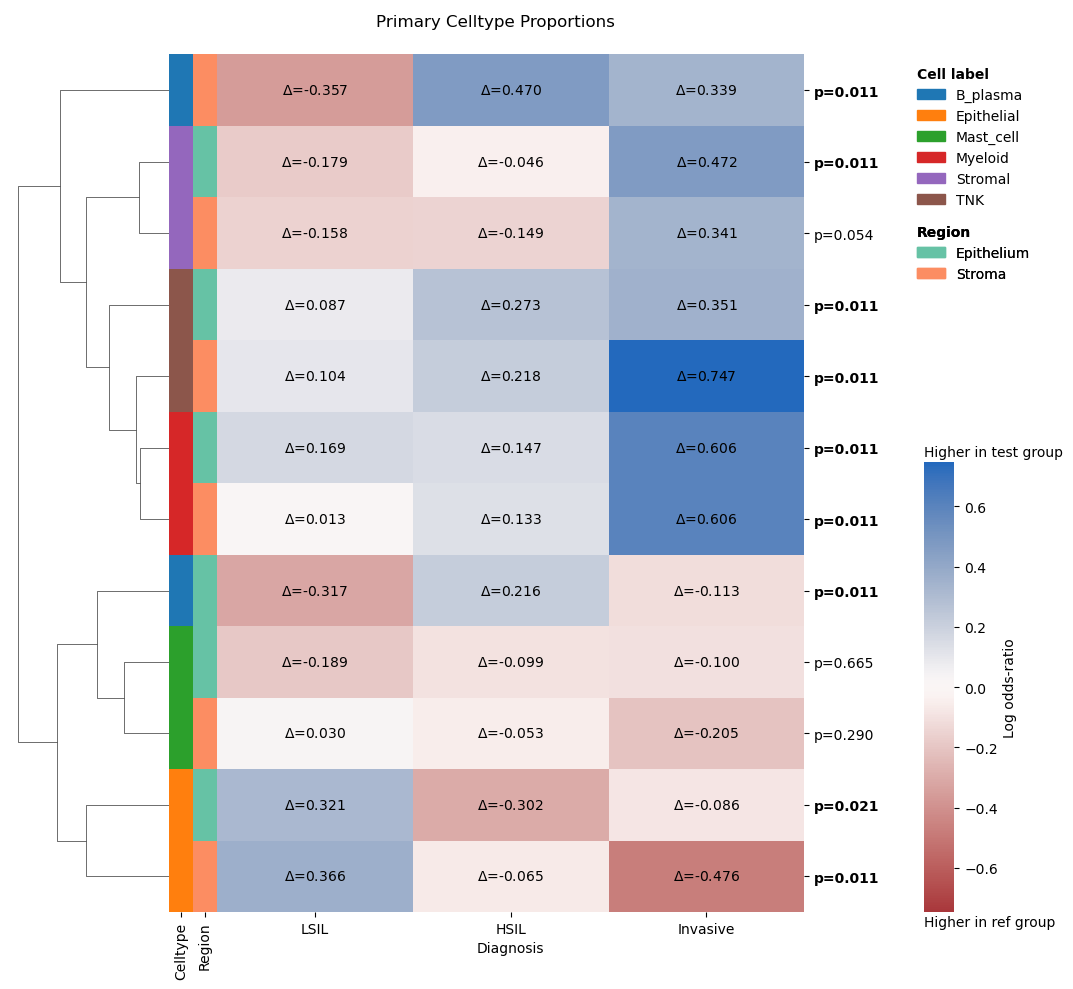

In [26]:
fig = plot_progression_heatmap(
    sub_res_df,                # Dataframe containing the stat results
    llr_df = sub_signif_df,   # Dataframe to label the categories p-values
    row_cluster = True,    # Cluster rows and plot the dendrogram
    index = ['Celltype', 'Region'],  # Index each row by unique celltype/region
    columns = ['Diagnosis'],          # Each diagnosis stage is its own column
    values = 'effect',               # Use the linear effect as the color value
    signif_col = 'signif',           # Column to indicate if feature is significant
    pval_col = 'fdr-q-val',          # Use the FDR adjusted q-value
    order = ['LSIL', 'HSIL', 'Invasive'], # Left to right order of columns
    ncols = 1, # Number of legend columns for the "Celltype" categories. (jank, ncol>1 only really works with niches)
    title = 'Primary Celltype Proportions',
    cbar_label = 'Log odds-ratio'      # Colorbar label. For proportions the logit link gives log odds-ratios
)

Plot one of the results to see if it makes sense

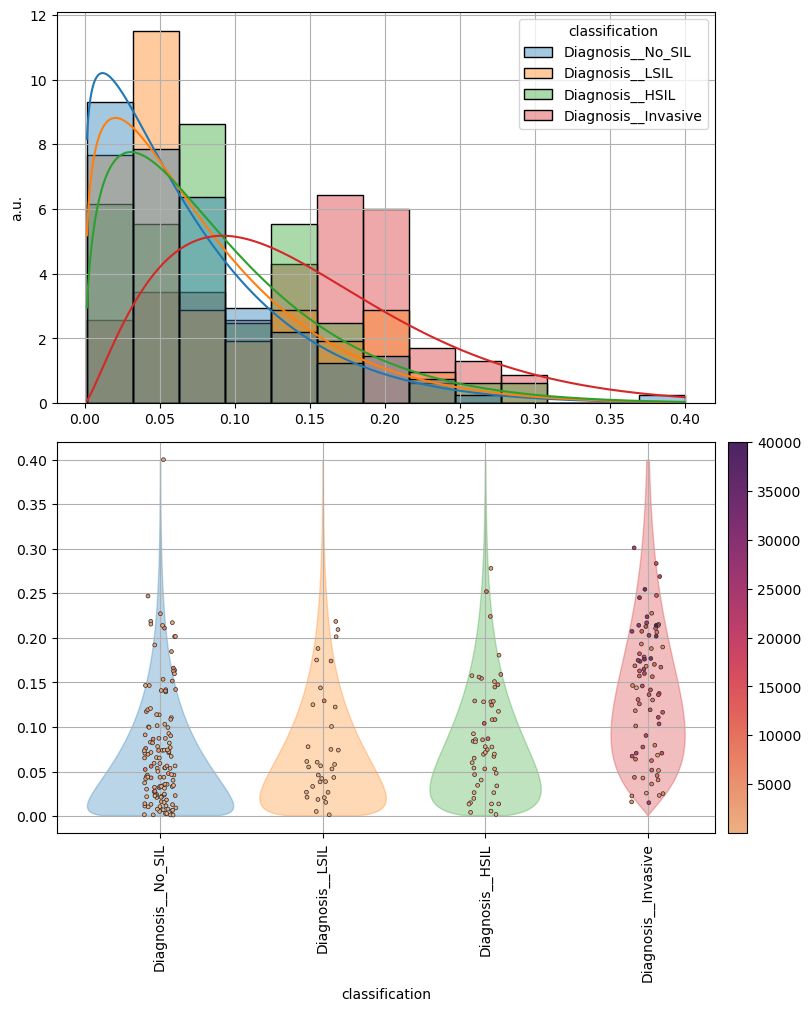

In [27]:
glms.plot_model(
    'primary_celltype_proportion_per_annot_region_2___TNK',
    fitted = True,
    order = ['Diagnosis__No_SIL', 'Diagnosis__LSIL', 'Diagnosis__HSIL', 'Diagnosis__Invasive'])

We can make the same plot for the spatial correlations with Epithelial fixed as the central cell type

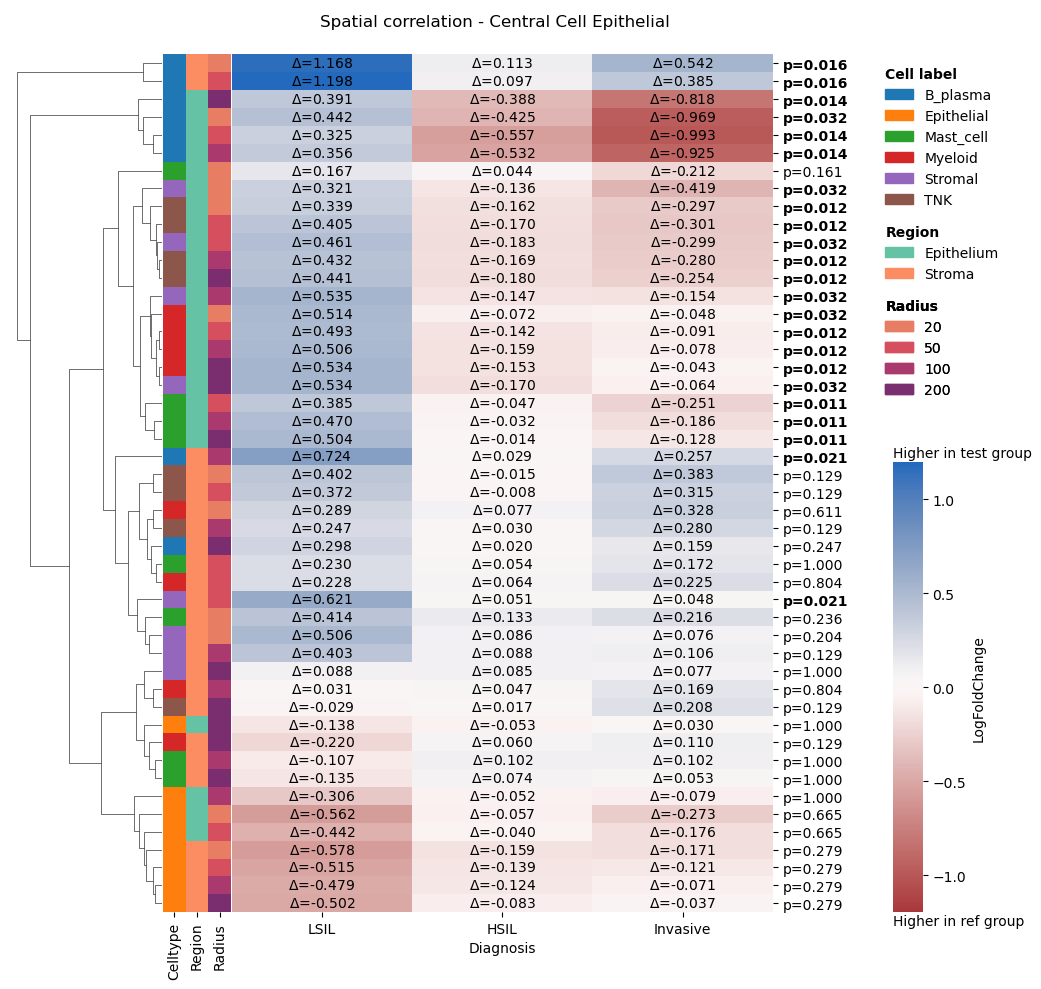

In [28]:
# select spatial correlations
feature = 'primary_celltype_spatial_correlation_central_cell_Epithelial'
sub_res_df = res_df[res_df['feature_type'] == feature].copy()

# Filter llr df to match the feature df
sub_llr_df = signif_df[signif_df['feature_type'] == feature].copy()

# We have to do some formatting, since we have spatial correlations for multiple radii
# Add a column for the radius
sub_res_df['Radius'] = sub_res_df['feature'].apply(lambda x: x.split('radius_')[1].split('_')[0]).astype(int)
sub_llr_df['Radius'] = sub_llr_df.index.to_series().apply(lambda x: x.split('radius_')[1].split('_')[0]).astype(int)

fig = plot_progression_heatmap(
    sub_res_df,                
    llr_df = sub_llr_df,
    row_cluster = True,
    index = ['Celltype', 'Region', 'Radius'],  #We've added radius to the list of indices
    columns = ['Diagnosis'],          
    values = 'effect', 
    signif_col = 'signif',
    pval_col = 'fdr-q-val',          
    order = ['LSIL', 'HSIL', 'Invasive'], 
    ncols = 1, 
    title = 'Spatial correlation - Central Cell Epithelial',
    cbar_label = 'LogFoldChange'      # Colorbar label is different since log link gives logfoldchanges
)

Plot one of the significant spatial correlations

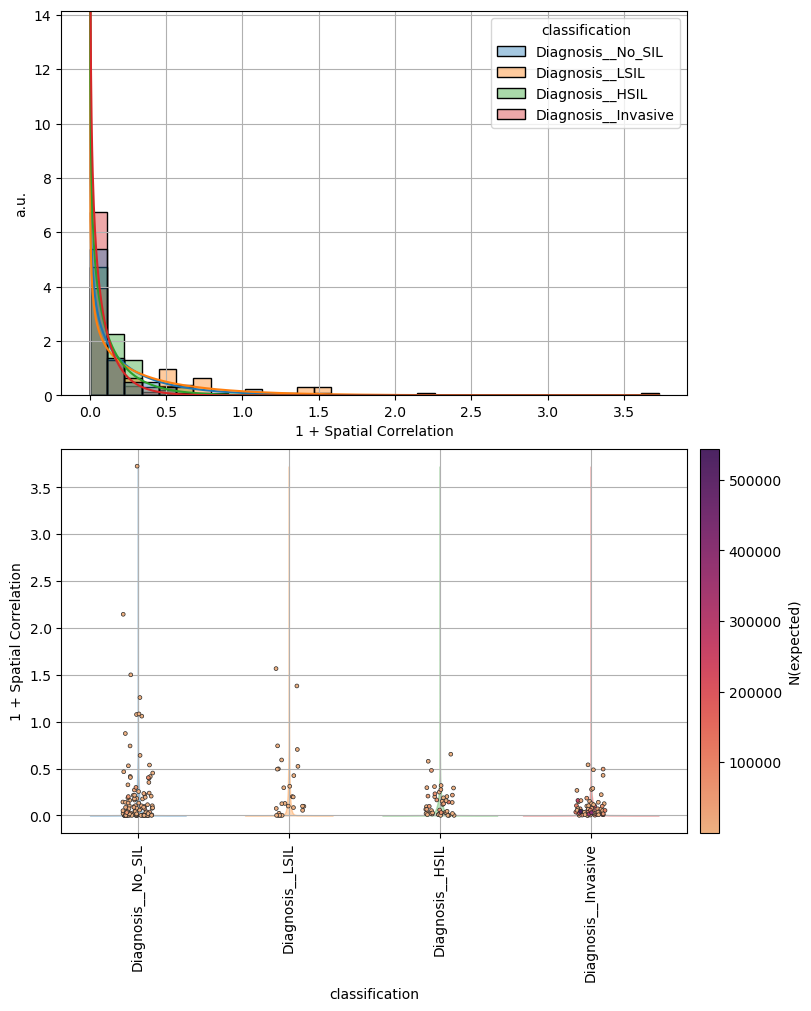

In [29]:
glms.plot_model(
    'primary_celltype_spatial_correlation_central_cell_Epithelial_radius_50_annot_region_3___B_plasma',
    fitted = True,
    ax_label = '1 + Spatial Correlation',
    cbar_label = 'N(expected)',
    order = ['Diagnosis__No_SIL', 'Diagnosis__LSIL', 'Diagnosis__HSIL', 'Diagnosis__Invasive'],
)

# Now we can make the full plots using posthoc comparisons

Make the dataframe for posthoc comparisons

In [30]:
posthoc_df = pd.DataFrame()
for key in stat_res:
    # Skip the llr results, we only want the pairwise comparisons
    if key == 'llr':
        continue
    tmp_df = stat_res[key]['df']
    for idx, row in tmp_df.iterrows():
        posthoc_df = pd.concat([posthoc_df, pd.DataFrame({'feature': [idx], 'group1':[f"{'___'.join([f'{cat}__{val}' for cat, val in stat_res[key]['ref_group'].items()])}"], 'group2':[f"{'___'.join([f'{cat}__{val}' for cat, val in stat_res[key]['test_group'].items()])}"], 'p-nom': [row['p-nom']]})], axis = 0, ignore_index = True)

# Filter out nans
posthoc_df = posthoc_df[~posthoc_df['p-nom'].isna()]

# Apply BH correction within each feature
posthoc_df['fdr-q-val'] = posthoc_df.groupby('feature')['p-nom'].transform(lambda x: false_discovery_control(x))
posthoc_df

,feature,group1,group2,p-nom,fdr-q-val
0,primary_celltype_proportion_per_annot_region_2...,Diagnosis__Invasive,Diagnosis__No_SIL,0.029703,0.035644
1,primary_celltype_proportion_per_annot_region_3...,Diagnosis__Invasive,Diagnosis__No_SIL,0.217822,0.217822
2,primary_celltype_proportion_per_annot_region_2...,Diagnosis__Invasive,Diagnosis__No_SIL,0.009901,0.019802
3,primary_celltype_proportion_per_annot_region_3...,Diagnosis__Invasive,Diagnosis__No_SIL,0.564356,0.564356
4,primary_celltype_proportion_per_annot_region_2...,Diagnosis__Invasive,Diagnosis__No_SIL,0.049505,0.148515
...,...,...,...,...,...
1795,primary_celltype_spatial_correlation_central_c...,Diagnosis__HSIL,Diagnosis__LSIL,0.178218,0.237624
1796,primary_celltype_spatial_correlation_central_c...,Diagnosis__HSIL,Diagnosis__LSIL,0.029703,0.059406
1797,primary_celltype_spatial_correlation_central_c...,Diagnosis__HSIL,Diagnosis__LSIL,0.039604,0.079208
1798,primary_celltype_spatial_correlation_central_c...,Diagnosis__HSIL,Diagnosis__LSIL,0.009901,0.019802


Now we can plot the fitted results and significances

Text(0.5, 0.98, 'primary_celltype_proportion_per_annot_region_2___TNK')

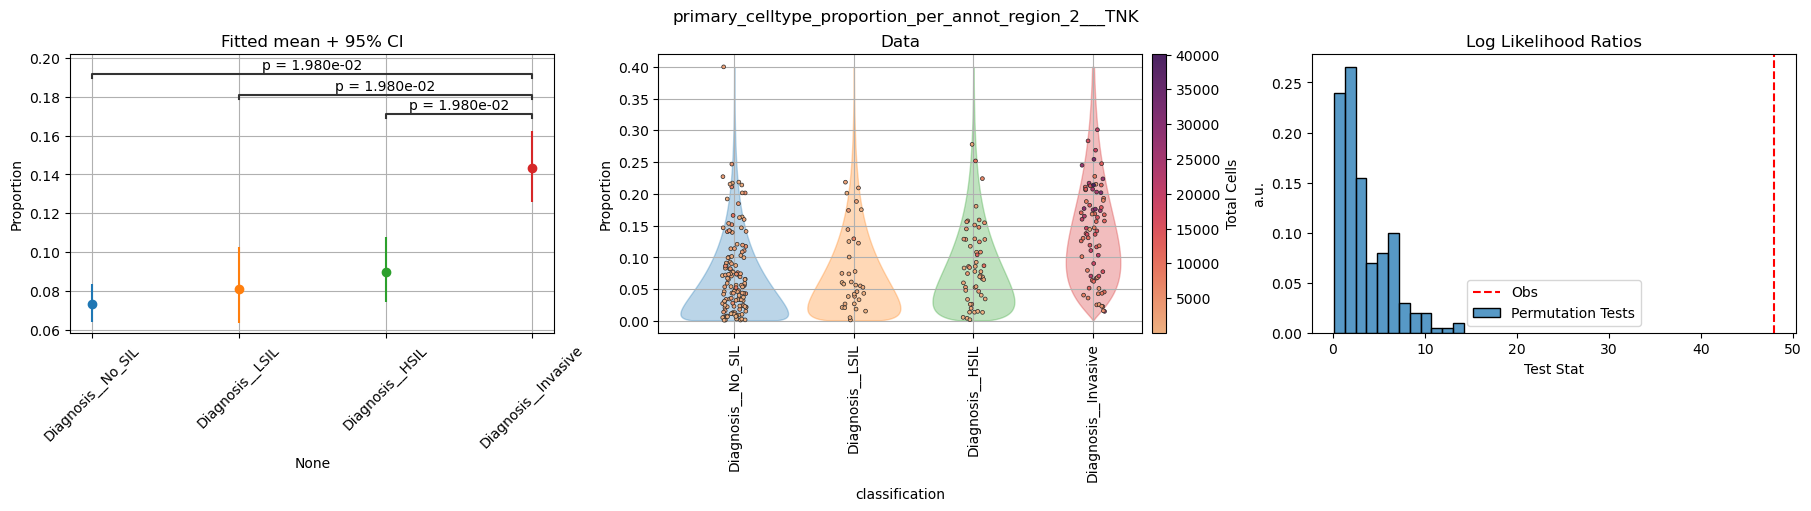

In [31]:
feature = 'primary_celltype_proportion_per_annot_region_2___TNK'
order = ['Diagnosis__No_SIL', 'Diagnosis__LSIL', 'Diagnosis__HSIL', 'Diagnosis__Invasive']
fig, ax = plt.subplots(1, 3, figsize = (18, 5), constrained_layout = True)

# Plot the fitted means + 95% confidence intervals
plot_posthoc(glms, posthoc_df, feature, order, ax = ax[0], ylabel = 'Proportion', title = 'Fitted mean + 95% CI')
# Plot the data using the stripplot + fitted pdf
glms.strip_plot(feature, fitted = True, order = order, ax = ax[1], ax_label = 'Proportion', cbar_label = 'Total Cells', title = 'Data')
# Plot the test statistic distributions
plot_test_stat(stat_res['llr']['perm_df'], stat_res['llr']['df'], feature, ax = ax[2])
fig.suptitle(feature)

Text(0.5, 0.98, 'primary_celltype_spatial_correlation_central_cell_Epithelial_radius_50_annot_region_3___B_plasma')

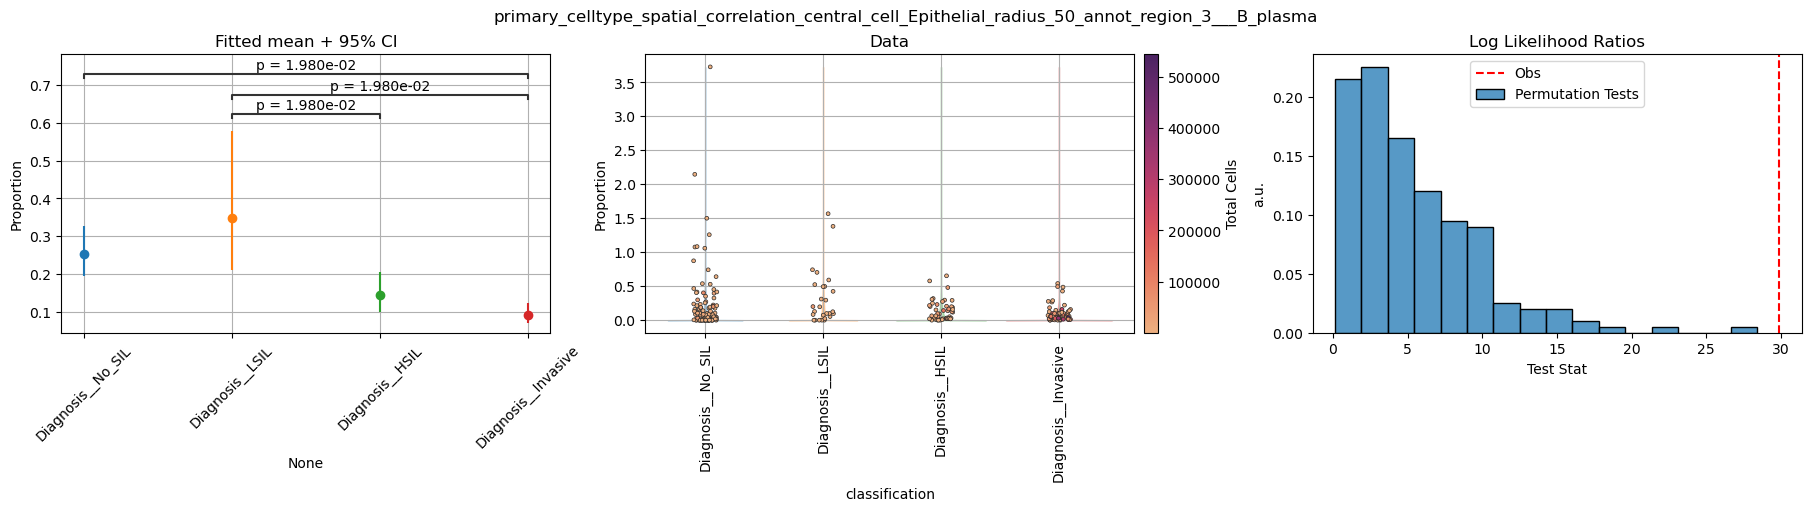

In [33]:
feature = 'primary_celltype_spatial_correlation_central_cell_Epithelial_radius_50_annot_region_3___B_plasma'
order = ['Diagnosis__No_SIL', 'Diagnosis__LSIL', 'Diagnosis__HSIL', 'Diagnosis__Invasive']
fig, ax = plt.subplots(1, 3, figsize = (18, 5), constrained_layout = True)

# Plot the fitted means + 95% confidence intervals
# hide_non_significant = False argument shows the p-values for all comparisons
plot_posthoc(glms, posthoc_df, feature, order, ax = ax[0], ylabel = 'Proportion', title = 'Fitted mean + 95% CI', hide_non_significant = True)
# Plot the data using the stripplot + fitted pdf
glms.strip_plot(feature, fitted = True, order = order, ax = ax[1], ax_label = 'Proportion', cbar_label = 'Total Cells', title = 'Data')
# Plot the test statistic distributions
plot_test_stat(stat_res['llr']['perm_df'], stat_res['llr']['df'], feature, ax = ax[2])
fig.suptitle(feature)